In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
#Preparacion de datos
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve)

from scipy import stats
df = pd.read_csv(r"C:\Users\kikid\Desktop\ProyectoM4_NicolasDiaz\Churn_Modelling.csv")


In [2]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [3]:
# Analisis de la variable objetivo: Exited (Churn)
print(df['Exited'].value_counts())
print()
churn_pct = df['Exited'].value_counts(normalize=True).mul(100).round(2)
print(churn_pct.rename({0: 'No Churn (0)', 1: 'Churn (1)'}).to_frame('Porcentaje (%)'))

Exited
0    7963
1    2037
Name: count, dtype: int64

              Porcentaje (%)
Exited                      
No Churn (0)           79.63
Churn (1)              20.37


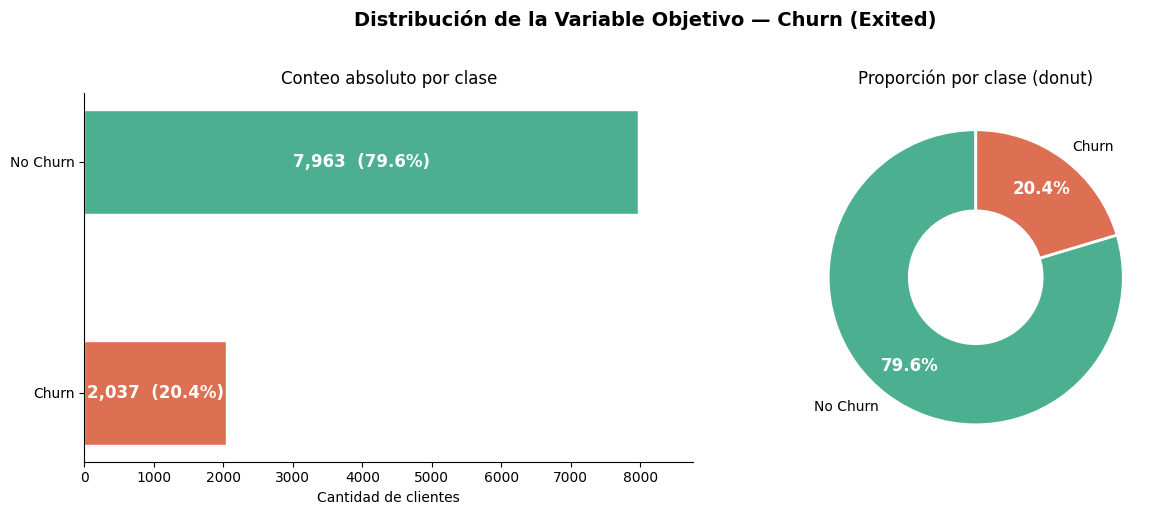

In [4]:
# Visualización: distribución de Churn
churn_counts = df['Exited'].value_counts()
churn_pct = df['Exited'].value_counts(normalize=True).mul(100).round(1)
labels = ['No Churn', 'Churn']
colors = ["#4CB090", "#DD7052"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribución de la Variable Objetivo — Churn (Exited)', fontsize=14, fontweight='bold', y=1.02)

# Barras horizontales con porcentaje
bars = axes[0].barh(labels, churn_counts.values, color=colors, edgecolor='white', height=0.45)
axes[0].set_xlabel('Cantidad de clientes')
axes[0].set_title('Conteo absoluto por clase')
axes[0].invert_yaxis()
for bar, count, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[0].text(bar.get_width() * 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{count:,}  ({pct}%)', va='center', ha='center',
                 fontsize=12, fontweight='bold', color='white')
axes[0].set_xlim(0, churn_counts.max() * 1.1)
axes[0].spines[['top', 'right']].set_visible(False)

#Grafico de pastel
wedges, texts, autotexts = axes[1].pie(
    churn_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    pctdistance=0.75
)
for t in autotexts:
    t.set(fontsize=12, fontweight='bold', color='white')
axes[1].set_title('Proporción por clase (donut)')

plt.tight_layout()
plt.show()

In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
#Exploracion de variables numericas vs variable objetivo (churn)
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'HasCrCard', 'IsActiveMember']

# Tabla resumen de medias/medianas por clase
resumen_num = (
    df.groupby('Exited')[num_cols]
      .agg(['mean', 'median'])
      .round(2)
)
print('Resumen numérico por clase (0 = No Churn, 1 = Churn):')
display(resumen_num)


Resumen numérico por clase (0 = No Churn, 1 = Churn):


CreditScore           Age        Tenure          Balance             \
              mean median   mean median   mean median      mean     median   
Exited                                                                       
0           651.85  653.0  37.41   36.0   5.03    5.0  72745.30   92072.68   
1           645.35  646.0  44.84   45.0   4.93    5.0  91108.54  109349.29   

       NumOfProducts        EstimatedSalary            HasCrCard         \
                mean median            mean     median      mean median   
Exited                                                                    
0               1.54    2.0        99738.39   99645.04      0.71    1.0   
1               1.48    1.0       101465.68  102460.84      0.70    1.0   

       IsActiveMember         
                 mean median  
Exited                        
0                0.55    1.0  
1                0.36    0.0

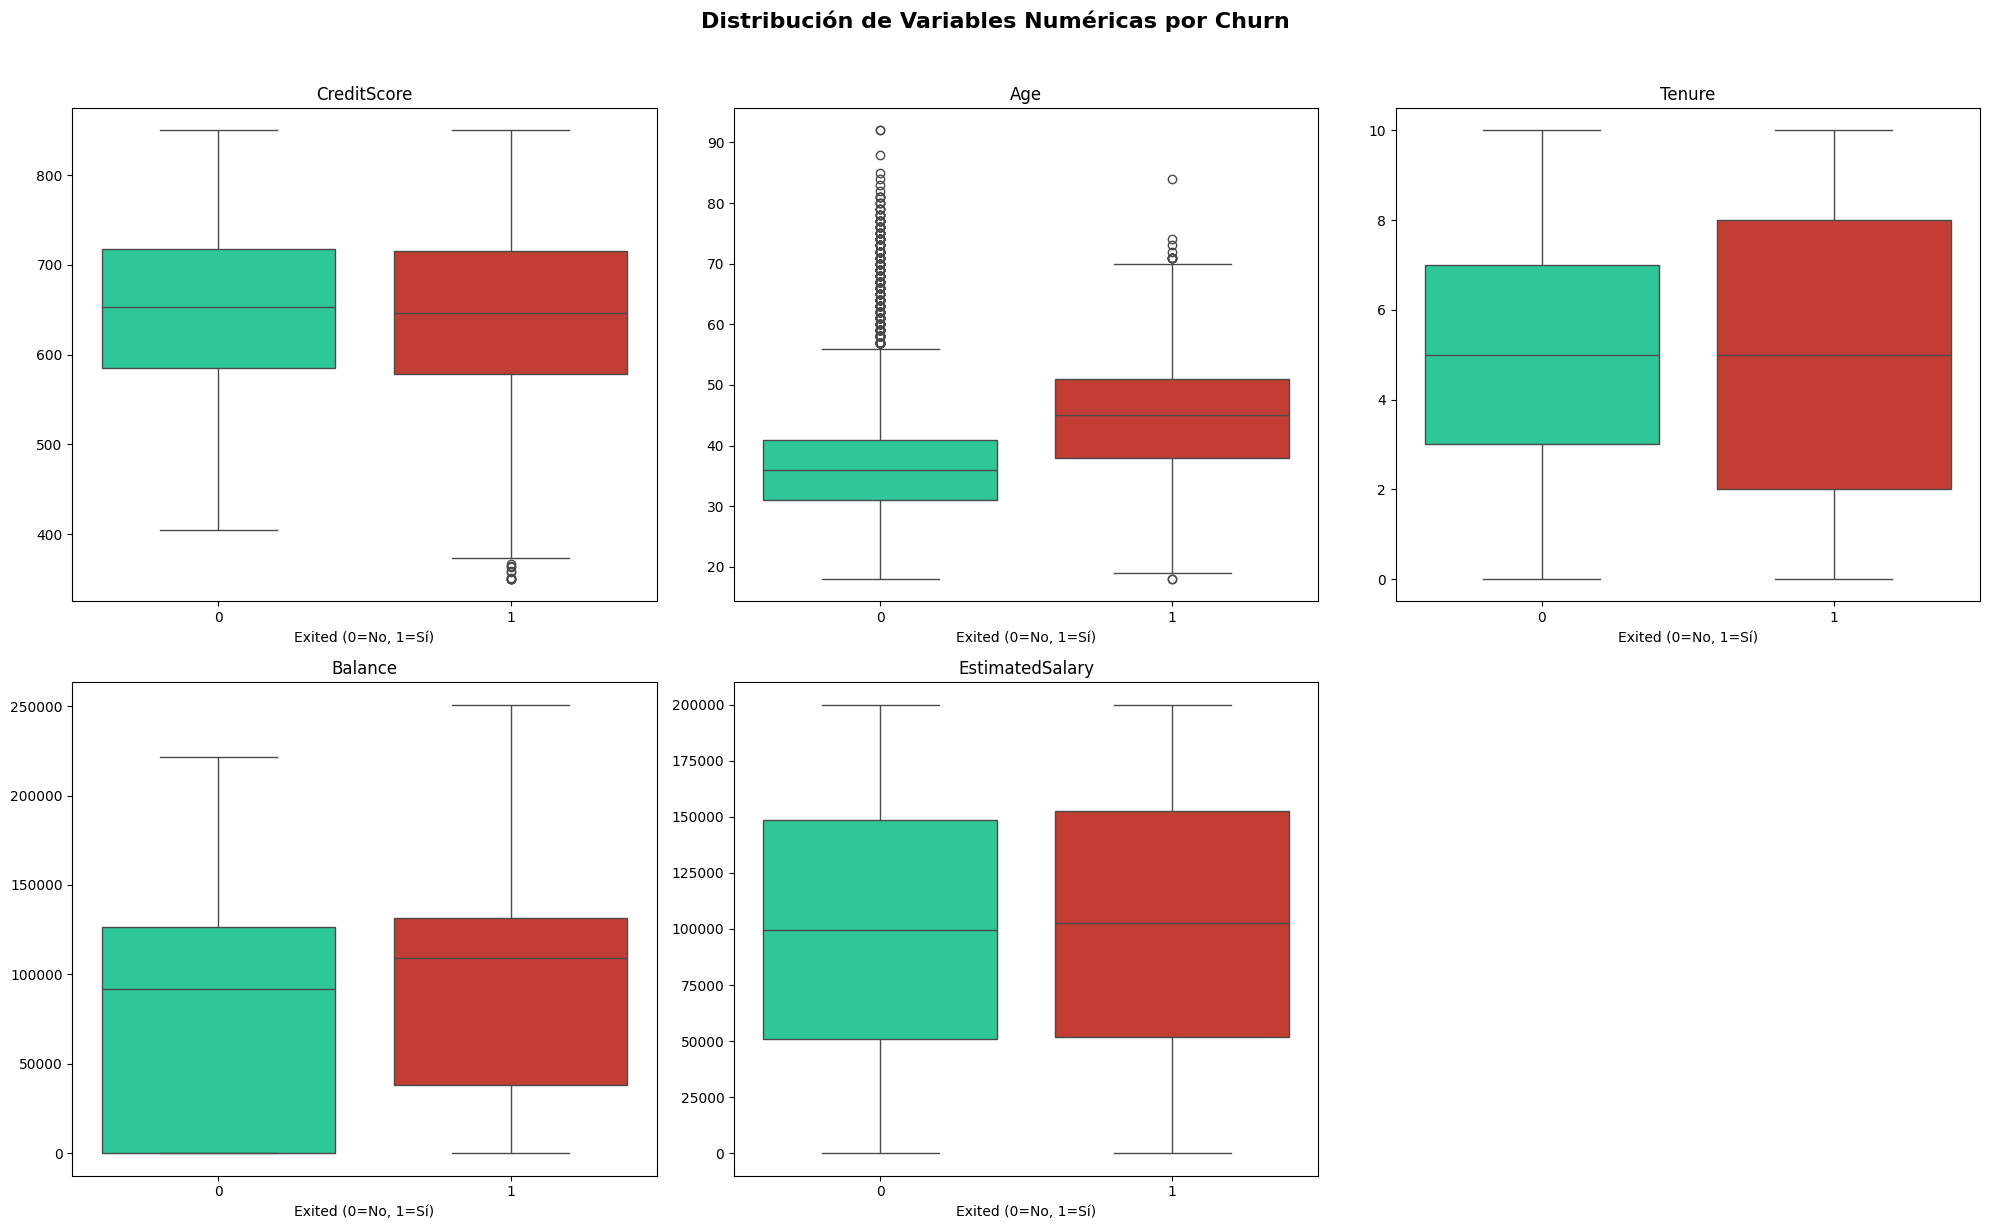

In [7]:
# Visualización comparativa
num_cols2 = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Distribución de Variables Numéricas por Churn', fontsize=16, fontweight='bold', y=1.02)

palette = {0: "#17E0A1", 1: "#DA281C"}

for i, col in enumerate(num_cols2):
    ax = axes[i//3, i%3]
    sns.boxplot(data=df, x='Exited', y=col, hue='Exited', palette=palette, legend=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Exited (0=No, 1=Sí)')
    ax.set_ylabel('')


# Ocultar el último subplot
axes[-1, -1].axis('off')

plt.tight_layout()
plt.show()

In [8]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
# Diferencia de medias (Churn - No Churn)
num_cols3 = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'HasCrCard', 'IsActiveMember']
diff_medias = (df[df['Exited'] == 1][num_cols3].mean() - df[df['Exited'] == 0][num_cols3].mean()).sort_values(ascending=False)
print('Diferencia de medias (Churn - No Churn):')
print(diff_medias.round(2).to_frame('Delta media'))

#Si sale positivo, los clientes que hicieron churn tienen un promedio mayor en esa variable. 
# Si sale negativo, los clientes que hicieron churn tienen un promedio menor en esa variable.
# Cuanto mayor sea el valor absoluto, mayor es la diferencia entre ambos grupos.

Diferencia de medias (Churn - No Churn):
                 Delta media
Balance             18363.24
EstimatedSalary      1727.29
Age                     7.43
HasCrCard              -0.01
NumOfProducts          -0.07
Tenure                 -0.10
IsActiveMember         -0.19
CreditScore            -6.50


#Variables categoricas vs variable objetivo (churn)


In [10]:

# Variables categóricas
cat_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'NumOfProducts']

# Tabla de tasa de churn por categoría
tablas_cat = {}
for col in cat_cols:
    tabla_resumen = (
        df.groupby(col)['Exited']
          .agg(clientes='count', churn_rate='mean')
          .assign(churn_rate_pct=lambda x: (x['churn_rate'] * 100).round(2))
          .sort_values('churn_rate_pct', ascending=False)
    )
    tablas_cat[col] = tabla_resumen

print('Tasa de churn por variable categórica:\n')
for col, tabla in tablas_cat.items():
    print(f'---------- {col} ---')
    print(tabla[['clientes', 'churn_rate_pct']])


Tasa de churn por variable categórica:

---------- Geography ---
           clientes  churn_rate_pct
Geography                          
Germany        2509           32.44
Spain          2477           16.67
France         5014           16.15
---------- Gender ---
        clientes  churn_rate_pct
Gender                          
Female      4543           25.07
Male        5457           16.46
---------- HasCrCard ---
           clientes  churn_rate_pct
HasCrCard                          
0              2945           20.81
1              7055           20.18
---------- IsActiveMember ---
                clientes  churn_rate_pct
IsActiveMember                          
0                   4849           26.85
1                   5151           14.27
---------- NumOfProducts ---
               clientes  churn_rate_pct
NumOfProducts                          
4                    60          100.00
3                   266           82.71
1                  5084           27.71
2        

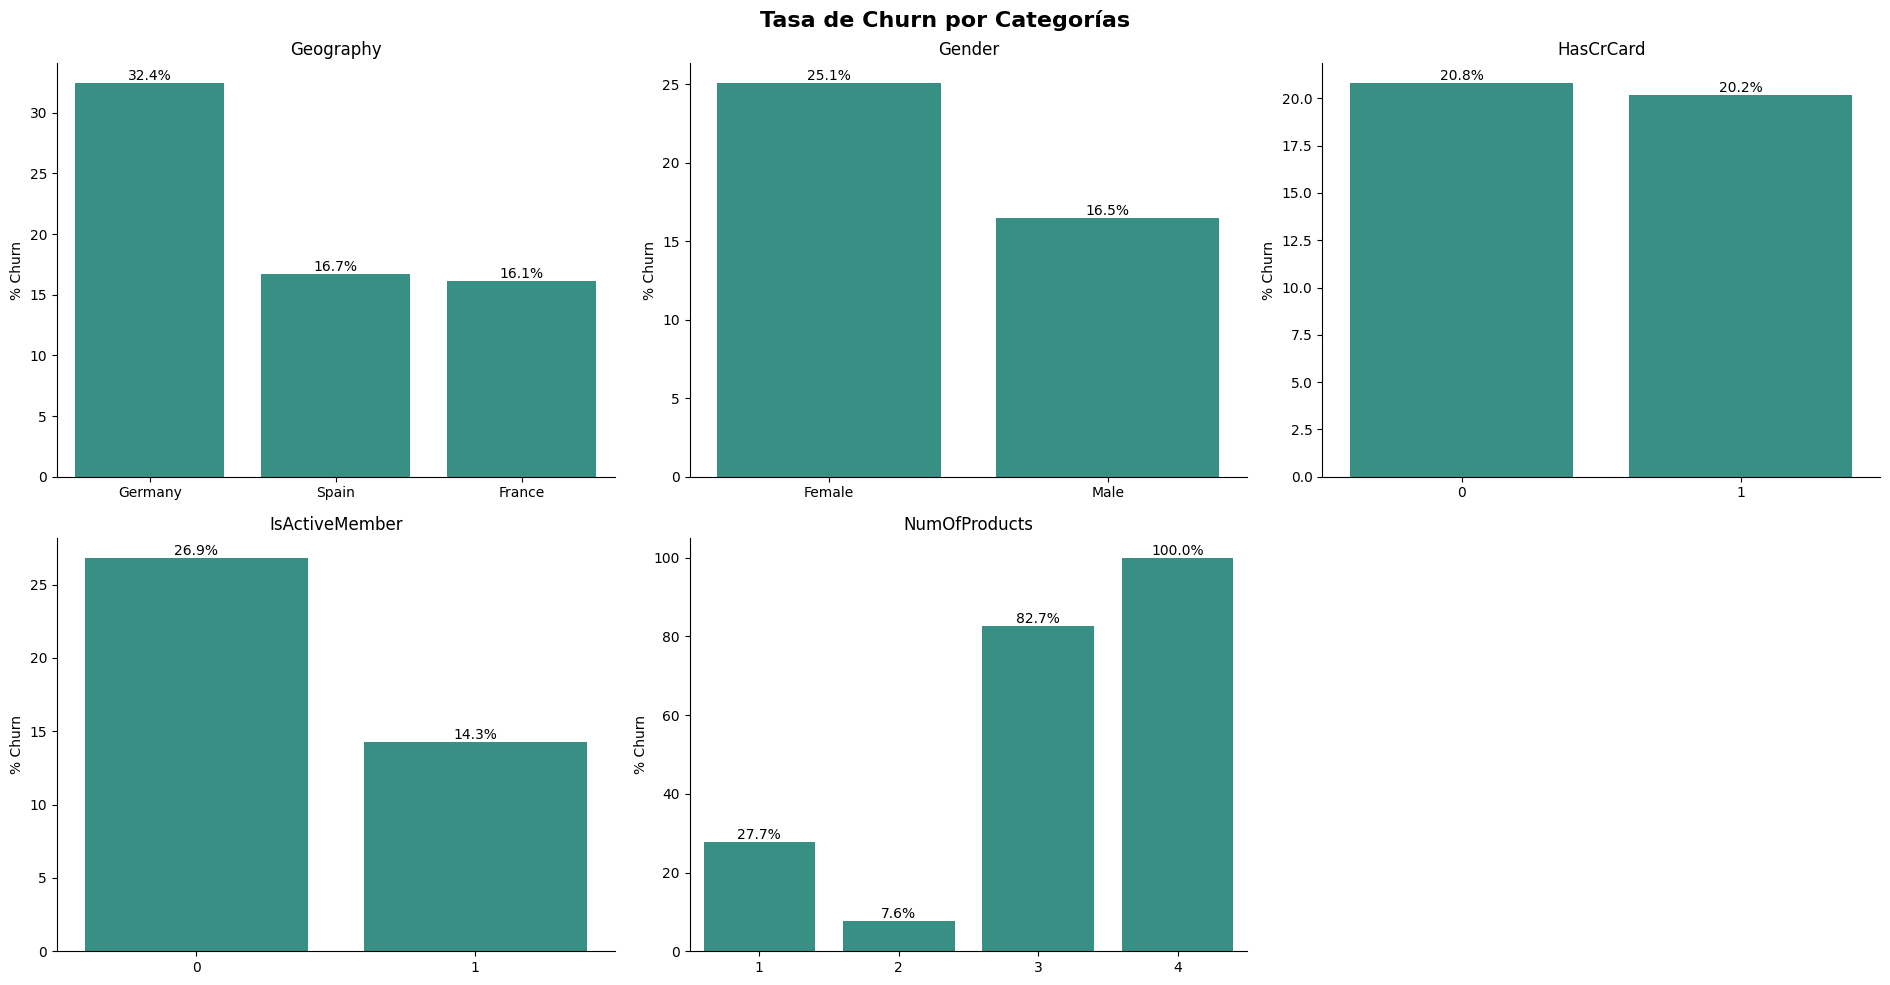

In [11]:
# Visualizaciones
fig, axes = plt.subplots(2, 3, figsize=(19, 10))
axes = axes.ravel()
fig.suptitle('Tasa de Churn por Categorías', fontsize=16, fontweight='bold')

plot_order = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'NumOfProducts']
bar_color = '#2A9D8F'

for i, col in enumerate(plot_order):
    plot_df = tablas_cat[col].reset_index()
    sns.barplot(data=plot_df, x=col, y='churn_rate_pct', color=bar_color, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('% Churn')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x')

    for p in axes[i].patches:
        h = p.get_height()
        axes[i].annotate(f'{h:.1f}%',
                         (p.get_x() + p.get_width() / 2, h),
                         ha='center', va='bottom', fontsize=10)
    axes[i].spines[['top', 'right']].set_visible(False)


axes[-1].axis('off')

plt.tight_layout()
plt.show()

In [12]:
#ranking general de categorías con más churn
ranking = []
for col, tabla in tablas_cat.items():
    top_cat = tabla['churn_rate_pct'].idxmax()
    top_rate = tabla['churn_rate_pct'].max()
    ranking.append({'Variable': col, '  Categoría con más churn': str(top_cat), 'Tasa (%)': top_rate})

ranking_df = pd.DataFrame(ranking)
print('Ranking resumido de riesgo por variable categórica:')
print(ranking_df)

Ranking resumido de riesgo por variable categórica:
         Variable   Categoría con más churn  Tasa (%)
0       Geography                   Germany     32.44
1          Gender                    Female     25.07
2       HasCrCard                         0     20.81
3  IsActiveMember                         0     26.85
4   NumOfProducts                         4    100.00


In [13]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


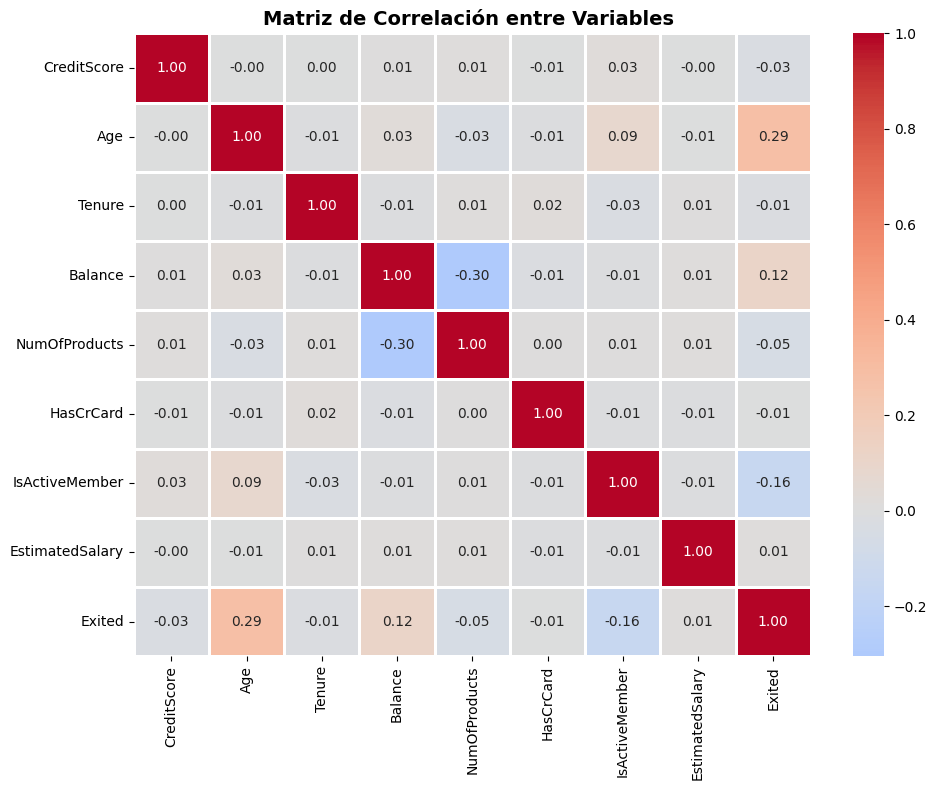

Correlación de cada variable con Churn (Exited):
Exited             1.000000
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
HasCrCard         -0.007138
Tenure            -0.014001
CreditScore       -0.027094
NumOfProducts     -0.047820
IsActiveMember    -0.156128
Name: Exited, dtype: float64


In [14]:
#Matriz de correlacion para variables
var_num=['CreditScore', 'Age','Tenure', 'Balance', 'NumOfProducts', 'HasCrCard','IsActiveMember', 'EstimatedSalary', 'Exited']

corr_ma = df[var_num].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_ma, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1, center=0)
plt.title('Matriz de Correlación entre Variables ', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlación de cada variable con Churn (Exited):')
print(corr_ma['Exited'].sort_values(ascending=False))

# Preparación de datos para Regresión Logística


In [15]:
##Limpieza y preparación de datos para modelado
# Se hace una copia del df original y se eliminan identificadores que no aportan al analisis
df_modelo = df.copy()

# 1) Dropear columnas irrelevantes para el modelo
df_modelo.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

#Verificar el resultado
print(f'\n Resultado de eliminacion de columnas irrelevantes:')
print((df_modelo.columns.to_list()))



 Resultado de eliminacion de columnas irrelevantes:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [16]:
#3) Encodificar variables categóricas

#Encoding de variable Gender
la_gen=LabelEncoder()
df_modelo['Gender'] = la_gen.fit_transform(df_modelo['Gender'])
print('\n Comprobacion de encoding de variable Gender')
print(f"Valores econtrados despues de encoding: {df_modelo['Gender'].unique()}")
print(f"Cantidad de valores despues de encoding: {df_modelo['Gender'].value_counts()}")

#Encoding de variable Geography
geography_dummies = pd.get_dummies(df_modelo['Geography'], prefix='Country', drop_first=True)
df_modelo = pd.concat([df_modelo, geography_dummies], axis=1)
df_modelo.drop('Geography', axis=1, inplace=True)
print('\n Comprobacion de encoding de variable Geography')
print(f"Columnas creadas: {geography_dummies.columns.to_list()}")
display(df_modelo.head())



 Comprobacion de encoding de variable Gender
Valores econtrados despues de encoding: [0 1]
Cantidad de valores despues de encoding: Gender
1    5457
0    4543
Name: count, dtype: int64

 Comprobacion de encoding de variable Geography
Columnas creadas: ['Country_Germany', 'Country_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Country_Germany,Country_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [17]:
# Verificación del mapeo de Gender
print('Mapeo Gender:', dict(zip(la_gen.classes_, la_gen.transform(la_gen.classes_))))

Mapeo Gender: {'Female': np.int64(0), 'Male': np.int64(1)}


In [18]:
# 2) Separar variables del objetivo
# Usamos las variables preparadas
X = df_modelo.drop(columns=['Exited'])
y = df_modelo['Exited']

print(f'\nCantidad variables X: {X.shape[1]}')
print(f'Variables restantes:\n {X.columns.to_list()}')
print('\nVariable objetivo (y): Exited')


Cantidad variables X: 11
Variables restantes:
 ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Country_Germany', 'Country_Spain']

Variable objetivo (y): Exited


In [19]:
# 3) Split train/test (80/20) 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('\nTAMAÑOS:')
print('=======================================')
print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('\n')
print('y_train:', y_train.shape, '| y_test:', y_test.shape)
print('y_train distribución (%)')
print(y_train.value_counts(normalize=True).mul(100).round(2))
print('y_test distribución (%)')
print(y_test.value_counts(normalize=True).mul(100).round(2))


TAMAÑOS:
X_train: (8000, 11) | X_test: (2000, 11)


y_train: (8000,) | y_test: (2000,)
y_train distribución (%)
Exited
0    79.62
1    20.38
Name: proportion, dtype: float64
y_test distribución (%)
Exited
0    79.65
1    20.35
Name: proportion, dtype: float64


In [20]:
#Escalar variables numericas

scaler = StandardScaler()
scaler.fit(X_train) # Se ajusta el scaler solo con los datos de entrenamiento para evitar data leakage
X_train_scaled = scaler.transform(X_train) # Se transforma el set de entrenamiento
X_test_scaled = scaler.transform(X_test) 
X_train_scaled=pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index) # Se convierte a DataFrame para mantener columnas e índices originales
X_test_scaled=pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print('Variables numericas antes de escalar')
print(X_train.iloc[:5,:5])
print('\n')
print('Variables numericas despues de escalar')
print(X_train_scaled.iloc[:5,:5])

Variables numericas antes de escalar
      CreditScore  Gender  Age  Tenure    Balance
2151          753       1   57       7       0.00
8392          739       1   32       3  102128.27
5006          755       0   37       0  113865.23
4117          561       1   37       5       0.00
7182          692       1   49       6  110540.43


Variables numericas despues de escalar
      CreditScore    Gender       Age    Tenure   Balance
2151     1.058568  0.907507  1.715086  0.684723 -1.226059
8392     0.913626  0.907507 -0.659935 -0.696202  0.413288
5006     1.079274 -1.101919 -0.184931 -1.731895  0.601687
4117    -0.929207  0.907507 -0.184931 -0.005739 -1.226059
7182     0.427035  0.907507  0.955079  0.339492  0.548318


In [21]:
# Exportar dataset preprocesado/escalado para Notebook 2 (Gradient Boosting)
import os

# Train escalado
train_scaled_df = X_train_scaled.copy()
train_scaled_df['Exited'] = y_train.values
train_scaled_df['split'] = 'train'

# Test escalado
test_scaled_df = X_test_scaled.copy()
test_scaled_df['Exited'] = y_test.values
test_scaled_df['split'] = 'test'

# Unir y guardar en un solo CSV
df_scaled_full = pd.concat([train_scaled_df, test_scaled_df], axis=0)
output_path = 'churn_preprocesado_escalado.csv'
df_scaled_full.to_csv(output_path, index=False)

print('CSV generado correctamente para Notebook 2:')
print(os.path.abspath(output_path))
print(f'Filas totales: {df_scaled_full.shape[0]} | Columnas: {df_scaled_full.shape[1]}')
print(df_scaled_full.head())

CSV generado correctamente para Notebook 2:
c:\Users\kikid\Desktop\ProyectoM4_NicolasDiaz\1.Notebooks\churn_preprocesado_escalado.csv
Filas totales: 10000 | Columnas: 13
      CreditScore    Gender       Age    Tenure   Balance  NumOfProducts  \
2151     1.058568  0.907507  1.715086  0.684723 -1.226059      -0.910256   
8392     0.913626  0.907507 -0.659935 -0.696202  0.413288      -0.910256   
5006     1.079274 -1.101919 -0.184931 -1.731895  0.601687       0.808830   
4117    -0.929207  0.907507 -0.184931 -0.005739 -1.226059       0.808830   
7182     0.427035  0.907507  0.955079  0.339492  0.548318       0.808830   

      HasCrCard  IsActiveMember  EstimatedSalary  Country_Germany  \
2151   0.641042       -1.030206         1.042084        -0.578313   
8392   0.641042       -1.030206        -0.623556         1.729169   
5006   0.641042        0.970680         0.308128         1.729169   
4117   0.641042       -1.030206        -0.290199        -0.578313   
7182  -1.559960        0.970

In [22]:
#Regresion lineal
#Creacion del modelo lineal
modelo_lr=LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs')

#Entrenamiento del modelo
modelo_lr.fit(X_train_scaled, y_train)

print('\nModelo de Regresión Logística entrenado con éxito.')
print('Coeficientes del modelo:')
print(f'iteraciones: {modelo_lr.n_iter_[0]}')
print(f'variables: {len(modelo_lr.coef_[0])}')


Modelo de Regresión Logística entrenado con éxito.
Coeficientes del modelo:
iteraciones: 6
variables: 11


In [23]:
# Coeficientes del modelo
coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': modelo_lr.coef_[0]
}).sort_values('Coeficiente', ascending=False)

print('Coeficientes de la regresion:')
print(coef_df.round(2))

Coeficientes de la regresion:
           Variable  Coeficiente
2               Age         0.74
9   Country_Germany         0.36
4           Balance         0.16
8   EstimatedSalary         0.05
10    Country_Spain         0.02
3            Tenure        -0.02
6         HasCrCard        -0.03
5     NumOfProducts        -0.07
0       CreditScore        -0.09
1            Gender        -0.26
7    IsActiveMember        -0.52


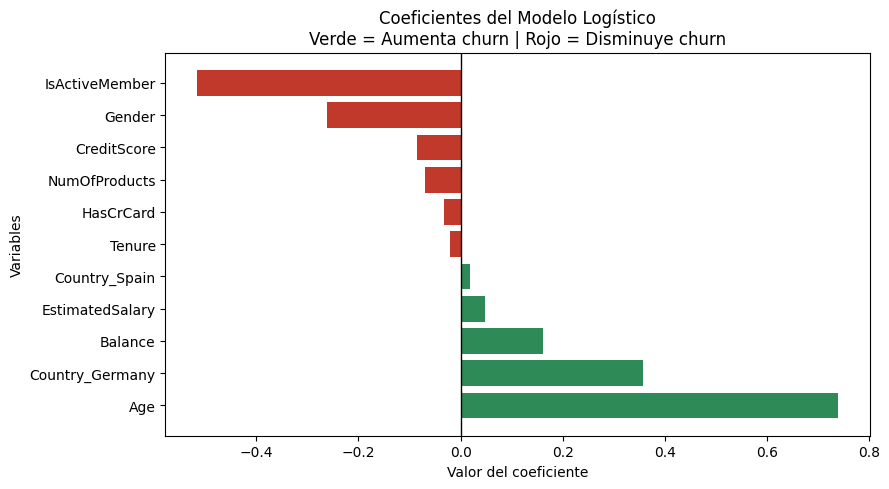

In [24]:
# Gráfico de coeficientes
plt.figure(figsize=(9, 5))

# Verde: coeficiente positivo (aumenta churn) | Rojo: coeficiente negativo (disminuye churn)
colors = ['#2E8B57' if c > 0 else '#C0392B' for c in coef_df['Coeficiente']]
plt.barh(coef_df['Variable'], coef_df['Coeficiente'], color=colors)
plt.axvline(0, color='black', linewidth=1)

plt.title('Coeficientes del Modelo Logístico\nVerde = Aumenta churn | Rojo = Disminuye churn')
plt.xlabel('Valor del coeficiente')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

In [25]:
# Odds Ratios
odds_df = coef_df.copy()
odds_df['Odds_Ratio'] = np.exp(odds_df['Coeficiente'])
odds_df['Cambio_%_odds'] = (odds_df['Odds_Ratio'] - 1) * 100

print('Odds ratios del modelo (OR = exp(coeficiente)):')
print(odds_df[['Variable', 'Coeficiente', 'Odds_Ratio', 'Cambio_%_odds']].round(2))

print('\nLectura rápida:')
print('- OR > 1: aumenta odds de churn')
print('- OR < 1: disminuye odds de churn')

Odds ratios del modelo (OR = exp(coeficiente)):
           Variable  Coeficiente  Odds_Ratio  Cambio_%_odds
2               Age         0.74        2.09         109.35
9   Country_Germany         0.36        1.43          42.86
4           Balance         0.16        1.17          17.42
8   EstimatedSalary         0.05        1.05           4.89
10    Country_Spain         0.02        1.02           1.91
3            Tenure        -0.02        0.98          -1.99
6         HasCrCard        -0.03        0.97          -3.17
5     NumOfProducts        -0.07        0.93          -6.79
0       CreditScore        -0.09        0.92          -8.24
1            Gender        -0.26        0.77         -22.96
7    IsActiveMember        -0.52        0.60         -40.28

Lectura rápida:
- OR > 1: aumenta odds de churn
- OR < 1: disminuye odds de churn


In [26]:
# Intervalos de confianza

X_mat = X_train_scaled.values
y_mat = y_train.values

# Agregamos intercepto al disenio
X_design = np.column_stack([np.ones(X_mat.shape[0]), X_mat])

# Probabilidades predichas del modelo entrenado
p_hat = modelo_lr.predict_proba(X_train_scaled)[:, 1]

# Matriz de pesos W = diag(p*(1-p))
w = p_hat * (1 - p_hat)
W = np.diag(w)

# Matriz de covarianza aproximada: (X'WX)^-1
XTWX = X_design.T @ W @ X_design
cov_beta = np.linalg.pinv(XTWX)
se_beta = np.sqrt(np.diag(cov_beta))

# Coeficientes (intercepto + variables)
beta = np.concatenate(([modelo_lr.intercept_[0]], modelo_lr.coef_[0]))
param_names = ['Intercept'] + X_train_scaled.columns.tolist()

# Valor critico
z = stats.norm.ppf(0.975)  # 95% CI

ci_low_beta = beta - z * se_beta
ci_high_beta = beta + z * se_beta

# Pasar a odds ratios
or_beta = np.exp(beta)
ci_low_or = np.exp(ci_low_beta)
ci_high_or = np.exp(ci_high_beta)

ci_df = pd.DataFrame({
    'Parametro': param_names,
    'Coef': beta,
    'SE': se_beta,
    'IC95%_Coef_Low': ci_low_beta,
    'IC95%_Coef_High': ci_high_beta,
    'OR': or_beta,
    'IC95%_OR_Low': ci_low_or,
    'IC95%_OR_High': ci_high_or
})

# Mostrar sin intercepto para lectura de negocio
ci_df_vars = ci_df[ci_df['Parametro'] != 'Intercept'].copy()
ci_df_vars = ci_df_vars.sort_values('OR', ascending=False)

print('Intervalos de confianza (95%) con SciPy - Odds Ratios')
print(ci_df_vars[['Parametro', 'OR', 'IC95%_OR_Low', 'IC95%_OR_High']].round(3))

print('\nRegla rapida:')
print('- Si el IC95% del OR incluye 1, el efecto puede no ser concluyente.')
print('- Si todo el IC95% esta por encima de 1, aumenta churn.')
print('- Si todo el IC95% esta por debajo de 1, disminuye churn.')

Intervalos de confianza (95%) con SciPy - Odds Ratios
          Parametro     OR  IC95%_OR_Low  IC95%_OR_High
3               Age  2.094         1.974          2.220
10  Country_Germany  1.429         1.340          1.523
5           Balance  1.174         1.094          1.260
9   EstimatedSalary  1.049         0.988          1.113
11    Country_Spain  1.019         0.953          1.090
4            Tenure  0.980         0.924          1.040
7         HasCrCard  0.968         0.913          1.027
6     NumOfProducts  0.932         0.878          0.990
1       CreditScore  0.918         0.865          0.974
2            Gender  0.770         0.726          0.817
8    IsActiveMember  0.597         0.561          0.636

Regla rapida:
- Si el IC95% del OR incluye 1, el efecto puede no ser concluyente.
- Si todo el IC95% esta por encima de 1, aumenta churn.
- Si todo el IC95% esta por debajo de 1, disminuye churn.


Evaluacion del modelo


In [27]:
# Predicciones para evaluación

y_pred = modelo_lr.predict(X_test_scaled)
y_pred_proba = modelo_lr.predict_proba(X_test_scaled)[:, 1]

pred_df = pd.DataFrame({
    'real': y_test.values[:10],
    'prediccion': y_pred[:10],
    'prob_churn': y_pred_proba[:10]
})

print('Primeras 10 predicciones del set de test:')
print(pred_df)

Primeras 10 predicciones del set de test:
   real  prediccion  prob_churn
0     0           0    0.118179
1     0           0    0.279476
2     0           0    0.112371
3     0           0    0.146706
4     0           0    0.095202
5     0           0    0.137029
6     0           0    0.086632
7     0           0    0.356268
8     0           0    0.355707
9     0           0    0.214598


In [28]:
# Métricas básicas del modelo
accuracy = accuracy_score(y_test, y_pred)

print('REPORTE DE CLASIFICACION')
print('\n')
print(classification_report(
    y_test,
    y_pred,
    target_names=['No Churn', 'Churn'],
    digits=4
))

report_dict = classification_report(y_test, y_pred, output_dict=True)
precision_churn = report_dict['1']['precision']
recall_churn = report_dict['1']['recall']
f1_churn = report_dict['1']['f1-score']

metricas_df = pd.DataFrame({
    'metrica': ['Accuracy', 'Precision_Churn', 'Recall_Churn', 'F1_Churn'],
    'valor': [accuracy, precision_churn, recall_churn, f1_churn]
})

print('RESUMEN DE METRICAS')
print('\n')
print(metricas_df.round(2))

print('\nInterpretación:')
if recall_churn < 0.5:
    print('- Recall bajo: se están escapando muchos churn reales.')
elif recall_churn < 0.7:
    print('- Recall moderado: se detecta una parte razonable de churn.')
else:
    print('- Recall alto: se detecta la mayoría de los churn.')

if precision_churn < 0.5:
    print('- Precision baja: hay muchas falsas alarmas de churn.')
elif precision_churn < 0.7:
    print('- Precision moderada: equilibrio aceptable entre aciertos y falsas alarmas.')
else:
    print('- Precision alta: pocas falsas alarmas cuando se predice churn.')

REPORTE DE CLASIFICACION


              precision    recall  f1-score   support

    No Churn     0.8231    0.9667    0.8891      1593
       Churn     0.5891    0.1867    0.2836       407

    accuracy                         0.8080      2000
   macro avg     0.7061    0.5767    0.5864      2000
weighted avg     0.7755    0.8080    0.7659      2000

RESUMEN DE METRICAS


           metrica  valor
0         Accuracy   0.81
1  Precision_Churn   0.59
2     Recall_Churn   0.19
3         F1_Churn   0.28

Interpretación:
- Recall bajo: se están escapando muchos churn reales.
- Precision moderada: equilibrio aceptable entre aciertos y falsas alarmas.


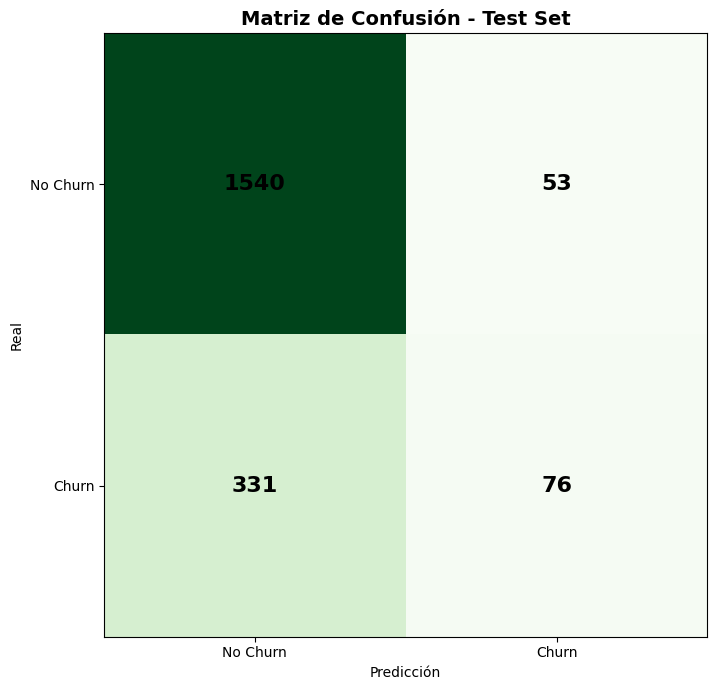


EXPLICACIÓN DE LA MATRIZ (TEST):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Arriba-izquierda (TN): Dijo NO CHURN y acertó
Arriba-derecha   (FP): Dijo CHURN pero no era
Abajo-izquierda  (FN): Dijo NO CHURN pero sí era churn
Abajo-derecha    (TP): Dijo CHURN y acertó


In [29]:
# Matriz de Confusión (solo TEST)

cm_test = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(cm_test, cmap='Greens')
ax.set_title('Matriz de Confusión - Test Set', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['No Churn', 'Churn'])
ax.set_yticklabels(['No Churn', 'Churn'])

# Anotaciones
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_test[i, j], ha='center', va='center', color='black', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nEXPLICACIÓN DE LA MATRIZ (TEST):')
print('━' * 60)
print('Arriba-izquierda (TN): Dijo NO CHURN y acertó')
print('Arriba-derecha   (FP): Dijo CHURN pero no era')
print('Abajo-izquierda  (FN): Dijo NO CHURN pero sí era churn')
print('Abajo-derecha    (TP): Dijo CHURN y acertó')

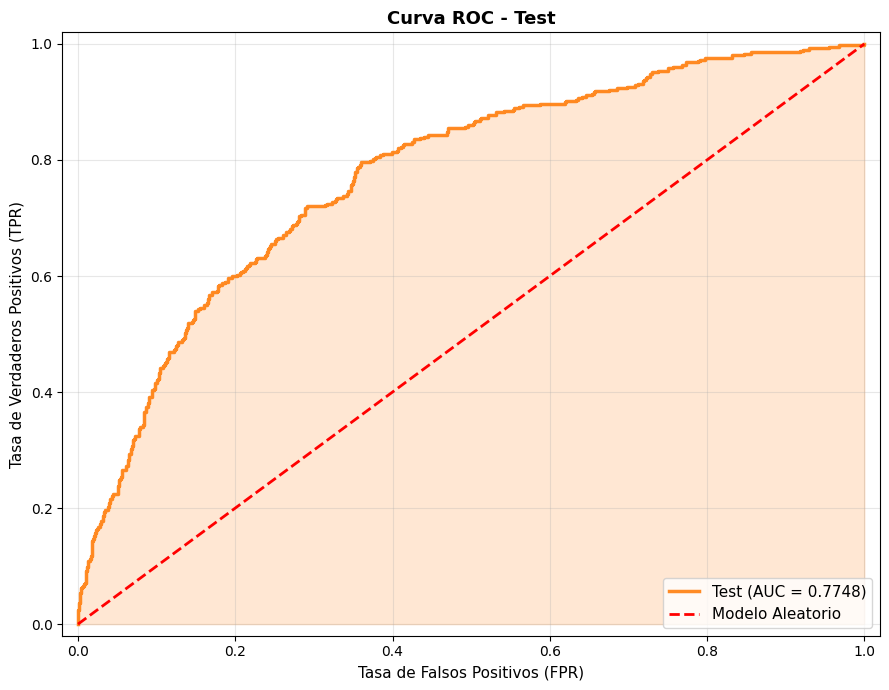


INTERPRETACIÓN AUC-ROC (TEST):


Test AUC: 0.7748

 BUENO: AUC > 0.7 → Modelo tiene buen poder de discriminación

¿QUÉ SIGNIFICA AUC?
  • AUC = 1.0  → Clasificación perfecta
  • AUC = 0.5  → Modelo igual a tirar una moneda
  • AUC = 0.0  → Clasificación inversa (predice al revés)

REGLA RÁPIDA:
  > Cuanto más a la izquierda y arriba la curva, mejor es el modelo


In [30]:
# Curva ROC-AUC

# Calcular AUC y curva ROC con la probabilidad de test ya creada
auc_test = roc_auc_score(y_test, y_pred_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(9, 7))

# Curva Test
ax.plot(fpr_test, tpr_test, color='#ff7f0e', lw=2.5,
        label=f'Test (AUC = {auc_test:.4f})', alpha=0.9)

# Rellenar el área bajo la curva
ax.fill_between(fpr_test, tpr_test, 0, color='#ff7f0e', alpha=0.18)

# Línea diagonal (modelo aleatorio)
ax.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Modelo Aleatorio')

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title('Curva ROC - Test', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.show()

print('\nINTERPRETACIÓN AUC-ROC (TEST):')
print('\n')
print(f'Test AUC: {auc_test:.4f}')
print()

if auc_test > 0.8:
    print('EXCELENTE: AUC > 0.8 → Modelo discrimina bien entre clases')
elif auc_test > 0.7:
    print(' BUENO: AUC > 0.7 → Modelo tiene buen poder de discriminación')
elif auc_test > 0.6:
    print(' ACEPTABLE: AUC > 0.6 → Modelo tiene poder de discriminación aceptable')
else:
    print(' DÉBIL: AUC ≤ 0.6 → Modelo no diferencia bien las clases')

print()
print('¿QUÉ SIGNIFICA AUC?')
print('  • AUC = 1.0  → Clasificación perfecta')
print('  • AUC = 0.5  → Modelo igual a tirar una moneda')
print('  • AUC = 0.0  → Clasificación inversa (predice al revés)')
print()
print('REGLA RÁPIDA:')
print('  > Cuanto más a la izquierda y arriba la curva, mejor es el modelo')

In [31]:
# RESUMEN FINAL DE EVALUACIÓN DEL MODELO
print('\n')
print( 'RESUMEN FINAL DE EVALUACIÓN' )
print()

print('RENDIMIENTO GENERAL:')
print('   El modelo acertó en 80.8% de todos los casos (Accuracy)')
print('   Pero solo encuentra el 18.7% de los clientes que realmente harán churn (Recall bajo)')
print('   De los que predice churn, acertó en 58.9% (Precision regular)')
print()

print('PROBLEMA PRINCIPAL:')
print('  El modelo no es del todo preciso: Predice muy pocos churns')
print('   Arriba-derecha de la matriz: casi vacía (muy pocos "Falsos Positivos")')
print('   Abajo-izquierda de la matriz: muy llena (muchos "Falsos Negativos")')
print()

print('PODER DE DISCRIMINACIÓN:')
print('  AUC = 0.7748 → BUENO (mejor que 0.5 que es adivinar)')
print('  El modelo diferencia bien entre clases, pero no es excelente')
print()

print('CONCLUSIÓN:')
print('  El modelo es CONFIABLE para:')
print('   Identificar clientes de ALTO RIESGO (si predice churn, probablemente es cierto)')
print('   Pero NO es bueno para capturar TODOS los clientes en riesgo')
print()





RESUMEN FINAL DE EVALUACIÓN

RENDIMIENTO GENERAL:
   El modelo acertó en 80.8% de todos los casos (Accuracy)
   Pero solo encuentra el 18.7% de los clientes que realmente harán churn (Recall bajo)
   De los que predice churn, acertó en 58.9% (Precision regular)

PROBLEMA PRINCIPAL:
  El modelo no es del todo preciso: Predice muy pocos churns
   Arriba-derecha de la matriz: casi vacía (muy pocos "Falsos Positivos")
   Abajo-izquierda de la matriz: muy llena (muchos "Falsos Negativos")

PODER DE DISCRIMINACIÓN:
  AUC = 0.7748 → BUENO (mejor que 0.5 que es adivinar)
  El modelo diferencia bien entre clases, pero no es excelente

CONCLUSIÓN:
  El modelo es CONFIABLE para:
   Identificar clientes de ALTO RIESGO (si predice churn, probablemente es cierto)
   Pero NO es bueno para capturar TODOS los clientes en riesgo

